# Project: Tomographic reconstruction with Huber regularization (3D reconstruction)

The noise in the 3D data has a relative norm of about 1/100, so we use $\delta = 0.01 \|y\|$.
The parameters $\epsilon$ and $\tau$ are taken from the 2D tests (`project_2d.ipynb`).
The functions shared with the 2D notebook are in `utils.py`.

In [1]:
%cd InverseProblems-Labs/project

/home/jupyter-miniproject8/InverseProblems-Labs/project


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import odl
from odl.applications import tomo
from odl.contrib.tomo import elekta_icon_geometry

from utils import save_figure, show_images, show_slices, axial_slice, huber_reconstruction, parker_weights

In [3]:
eps = 1e-3  # chosen in the 2D tests
tau = 1.1
scalings = [1.0, 0.5, 0.25]

In [4]:
reco_space = odl.uniform_discr([-112, -112, 0], [112, 112, 224], (128, 128, 128), dtype='float32')
geometry = elekta_icon_geometry(num_angles=128)
ray_trafo = tomo.RayTransform(vol_space=reco_space, geometry=geometry)
data_space = ray_trafo.range

data_path = '/home/jupyter-miniproject8/InverseProblems-Labs/noisy_sinogram.npy'
data = data_space.element(np.load(data_path).astype('float32', copy=False))

delta_3d = 0.01 * data.norm()
print(f'Data shape: {data_space.shape}, delta = {delta_3d:.2f}')

Data shape: (128, 780, 720), delta = 701.27


## Filtered back-projection in 3D

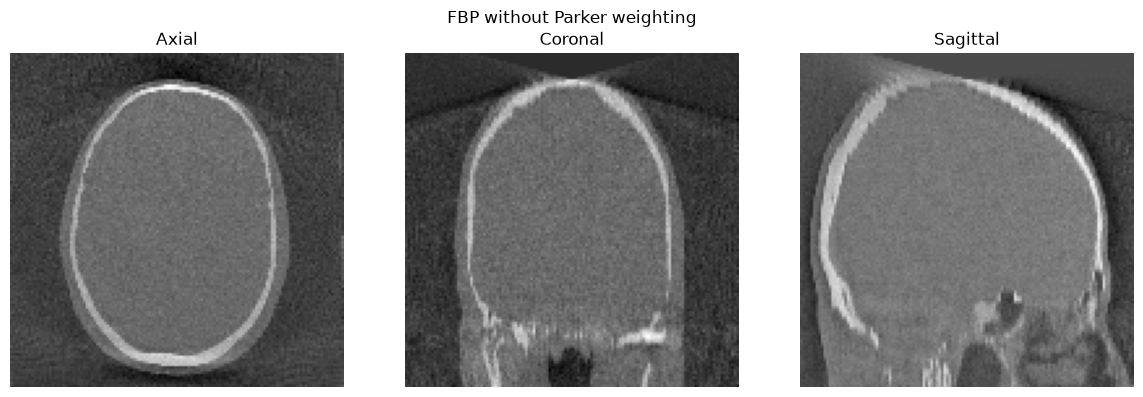

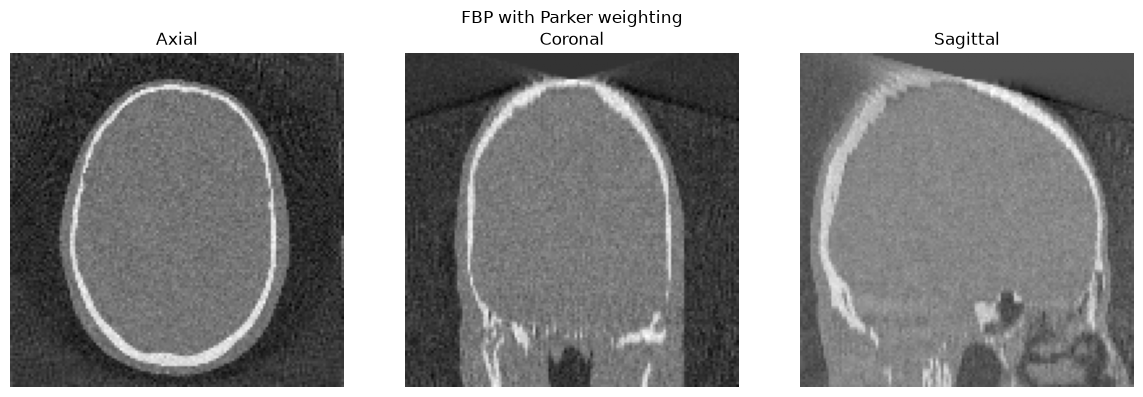

min = -1.930, max = 3.692


In [5]:
fbp = tomo.fbp_op(ray_trafo)
show_slices(fbp(data), 'FBP without Parker weighting', filename='fbp_3d_no_parker')

# the weighted data is computed once and reused for all the FBPs, to save memory
weighted_data = parker_weights(ray_trafo) * data
x_fbp_3d = fbp(weighted_data)
show_slices(x_fbp_3d, 'FBP with Parker weighting', filename='fbp_3d_parker')
print(f'min = {odl.min(x_fbp_3d):.3f}, max = {odl.max(x_fbp_3d):.3f}')

In [6]:
# display window centred on the brain values (central block of the FBP volume)
brain = x_fbp_3d.asarray()[48:80, 48:80, 60:68]
print(f'brain: mean = {brain.mean():.3f}, std = {brain.std():.3f}')
clim_3d = (brain.mean() - 3 * brain.std(), brain.mean() + 3 * brain.std())

brain: mean = 1.084, std = 0.139


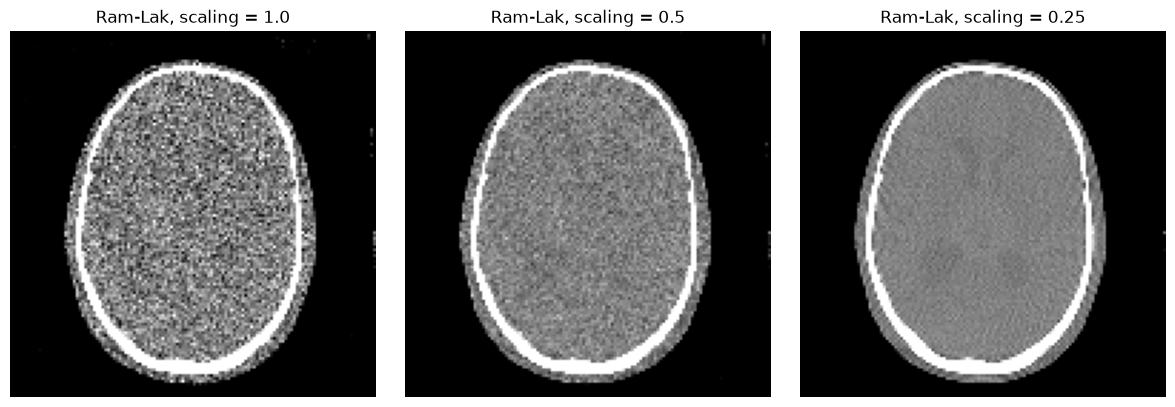

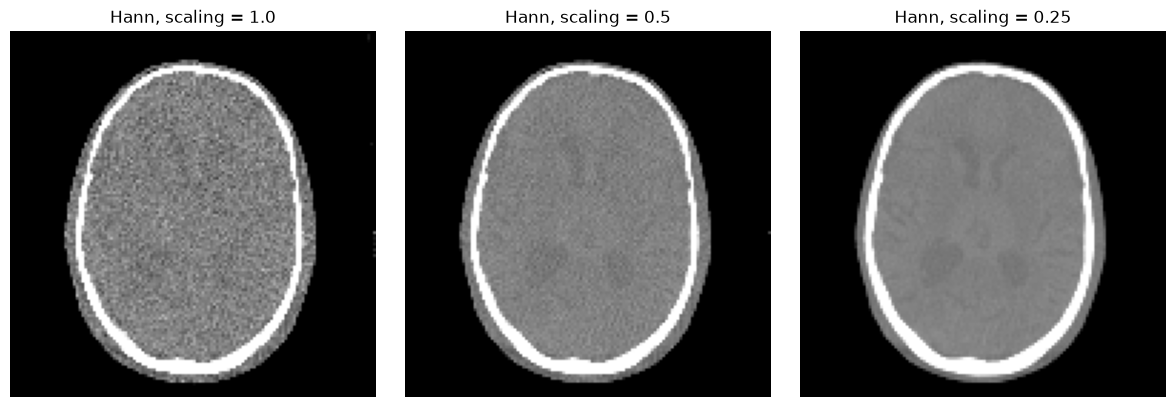

In [7]:
for filter_type in ['Ram-Lak', 'Hann']:
    images = []
    for scaling in scalings:
        fbp = tomo.fbp_op(ray_trafo, filter_type=filter_type, frequency_scaling=scaling)
        images.append(axial_slice(fbp(weighted_data)))
    show_images(images, [f'{filter_type}, scaling = {scaling}' for scaling in scalings], clim=clim_3d,
                filename=f'fbp_3d_{filter_type}')

x_hann_3d = tomo.fbp_op(ray_trafo, filter_type='Hann', frequency_scaling=0.25)(weighted_data)

# the weighted data is not needed anymore, this frees memory for the Huber reconstructions
del weighted_data

## Huber reconstruction in 3D

In [8]:
t = time.time()
ray_trafo_norm = float(ray_trafo.norm(estimate=True))
grad_norm = float(odl.Gradient(reco_space).norm(estimate=True))
op_norms_3d = (ray_trafo_norm, grad_norm)
print(f'||A|| = {ray_trafo_norm:.2f}, ||grad|| = {grad_norm:.2f} ({time.time() - t:.0f} s)')

||A|| = 36.78, ||grad|| = 1.96 (33 s)


### Short test to measure the time per iteration

1.29 s per iteration
residual / delta = 15.632


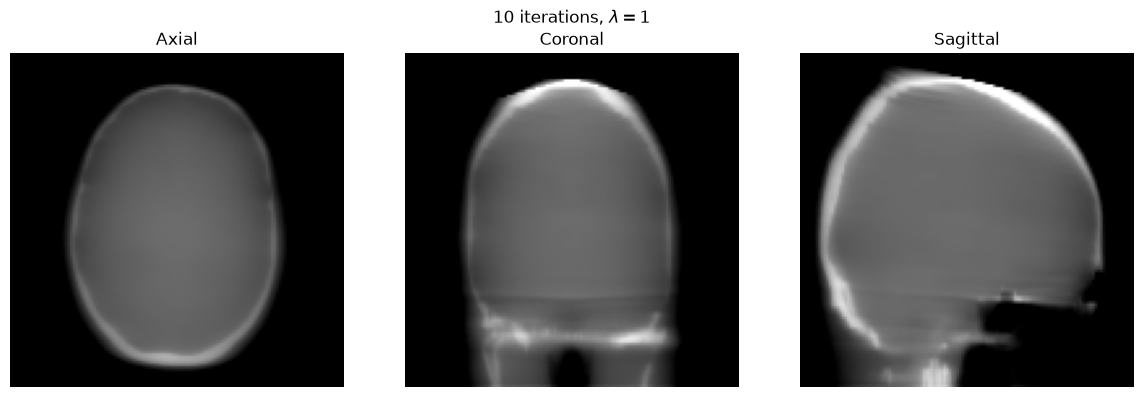

In [9]:
t = time.time()
x, _ = huber_reconstruction(ray_trafo, data, lam=1.0, eps=eps, niter=10, op_norms=op_norms_3d)
print(f'{(time.time() - t) / 10:.2f} s per iteration')
print(f'residual / delta = {(ray_trafo(x) - data).norm() / delta_3d:.3f}')
show_slices(x, r'10 iterations, $\lambda = 1$', clim=clim_3d, filename='huber_3d_test')

### Choice of $\lambda$ with Morozov's discrepancy principle

With $\delta = 0.01 \|y\|$ the residual never gets below about $1.34\delta$, even with almost no regularization,
so the data contains errors that the model cannot explain. We therefore estimate the total data error $\delta_{\text{eff}}$
as the residual of the almost unregularized reconstruction, and pick the first $\lambda$ with $\| A x - y \| \le \tau \delta_{\text{eff}}$.
Each $\lambda$ starts from the reconstruction of the previous one and is iterated until the residual
changes by less than 0.5% per 200 iterations, so that the residuals are compared at convergence.

In [10]:
lam_values_3d = [2.0, 1.5, 1.0, 0.3, 0.1, 0.01, 0.001]

recos_3d = []
ratios_3d = []
x = None
for lam in lam_values_3d:
    t = time.time()
    # continue in blocks of 200 iterations until the residual stops changing
    old_ratio = np.inf
    for k in range(15):
        x, _ = huber_reconstruction(ray_trafo, data, lam, eps, 200, op_norms_3d, x0=x)
        ratio = (ray_trafo(x) - data).norm() / delta_3d
        if old_ratio - ratio < 0.005 * ratio:
            break
        old_ratio = ratio
    recos_3d.append(x)
    ratios_3d.append(ratio)
    print(f'lambda = {lam}: residual / delta = {ratio:.3f} after {200 * (k + 1)} iterations ({time.time() - t:.0f} s)')

# residual of the almost unregularized reconstruction
delta_eff = min(ratios_3d) * delta_3d
print(f'delta_eff = {delta_eff / delta_3d:.3f} delta')

# first (largest) lambda that satisfies the discrepancy principle with delta_eff
for i_morozov_3d, ratio in enumerate(ratios_3d):
    if ratio * delta_3d <= tau * delta_eff:
        break
lam_morozov_3d = lam_values_3d[i_morozov_3d]
print(f'Morozov: lambda = {lam_morozov_3d}')

lambda = 2.0: residual / delta = 1.532 after 1600 iterations (1166 s)
lambda = 1.5: residual / delta = 1.488 after 600 iterations (492 s)
lambda = 1.0: residual / delta = 1.445 after 600 iterations (501 s)
lambda = 0.3: residual / delta = 1.370 after 600 iterations (486 s)
lambda = 0.1: residual / delta = 1.347 after 400 iterations (292 s)
lambda = 0.01: residual / delta = 1.341 after 400 iterations (303 s)
lambda = 0.001: residual / delta = 1.340 after 400 iterations (308 s)
delta_eff = 1.340 delta
Morozov: lambda = 1.0


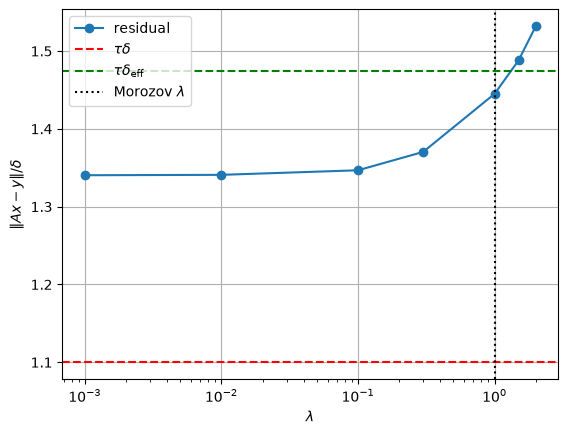

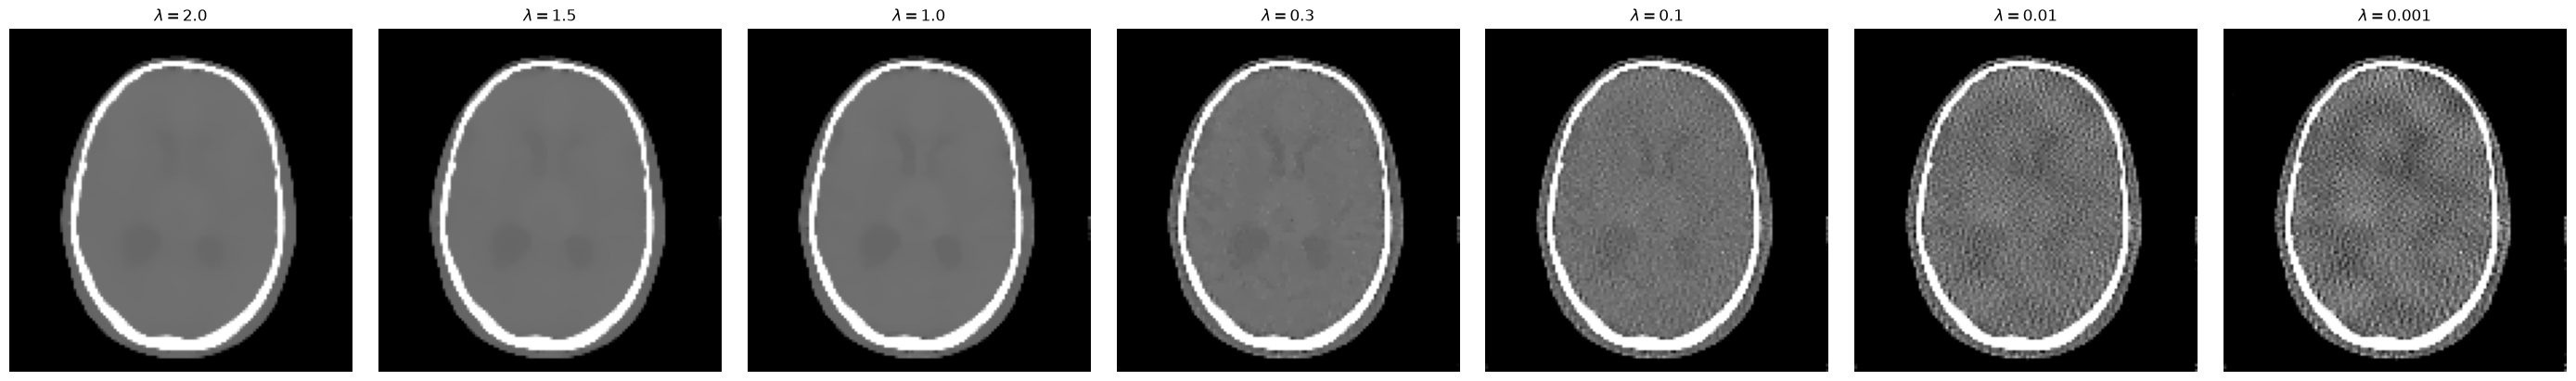

In [11]:
plt.figure()
plt.semilogx(lam_values_3d, ratios_3d, 'o-', label='residual')
plt.axhline(tau, color='r', linestyle='--', label=r'$\tau \delta$')
plt.axhline(tau * delta_eff / delta_3d, color='g', linestyle='--', label=r'$\tau \delta_{\mathrm{eff}}$')
plt.axvline(lam_morozov_3d, color='k', linestyle=':', label=r'Morozov $\lambda$')
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\|Ax - y\| / \delta$')
plt.grid(True)
plt.legend()
save_figure('morozov_3d')
plt.show()

show_images([axial_slice(x) for x in recos_3d], [rf'$\lambda = {lam}$' for lam in lam_values_3d], clim=clim_3d,
            filename='lambda_3d')

### Evolution with the number of iterations

10 iterations: residual / delta = 15.632
50 iterations: residual / delta = 4.562
200 iterations: residual / delta = 1.907
500 iterations: residual / delta = 1.517
1000 iterations: residual / delta = 1.453
2000 iterations: residual / delta = 1.442


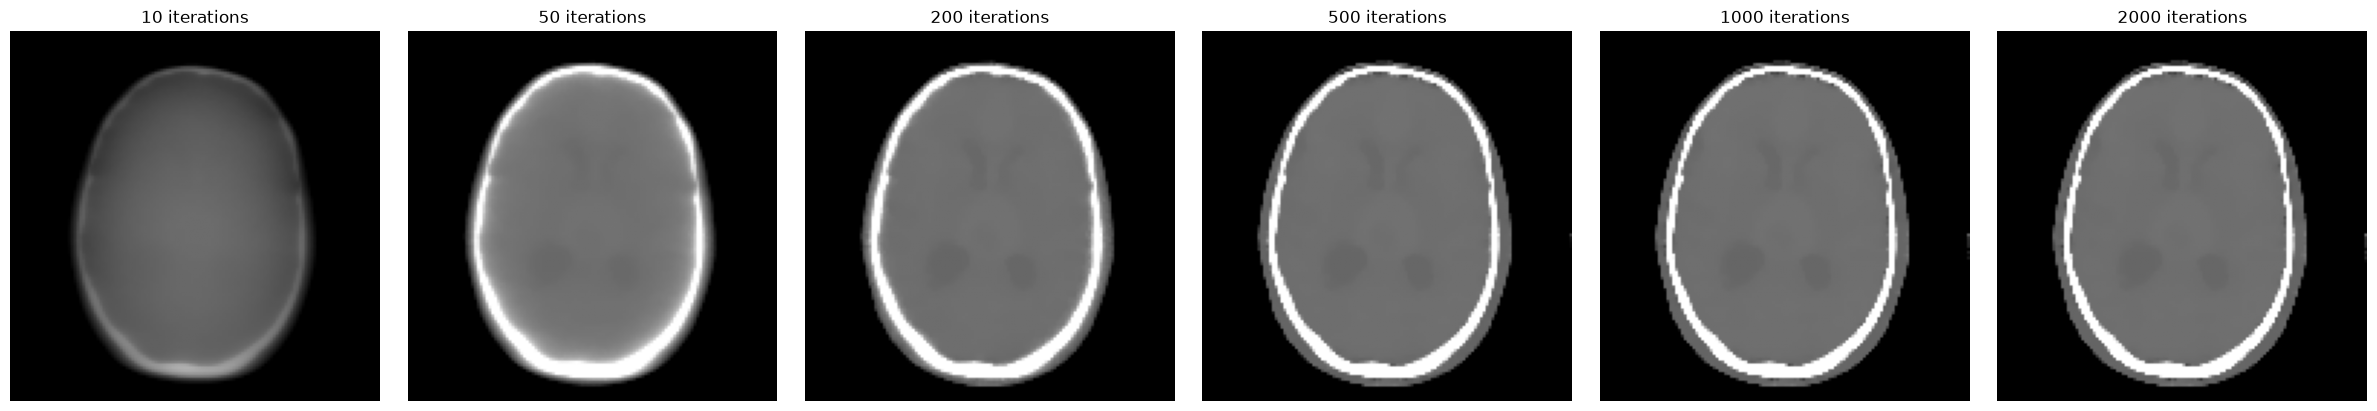

In [12]:
checkpoints = [10, 50, 200, 500, 1000, 2000]

# steepest descent with a constant step has no memory, so we can continue from the last iterate
iterates = []
x = None
done = 0
for k in checkpoints:
    x, _ = huber_reconstruction(ray_trafo, data, lam_morozov_3d, eps, k - done, op_norms_3d, x0=x)
    done = k
    iterates.append(x)
    print(f'{k} iterations: residual / delta = {(ray_trafo(x) - data).norm() / delta_3d:.3f}')

show_images([axial_slice(x) for x in iterates], [f'{k} iterations' for k in checkpoints], clim=clim_3d,
            filename='iterations_3d')

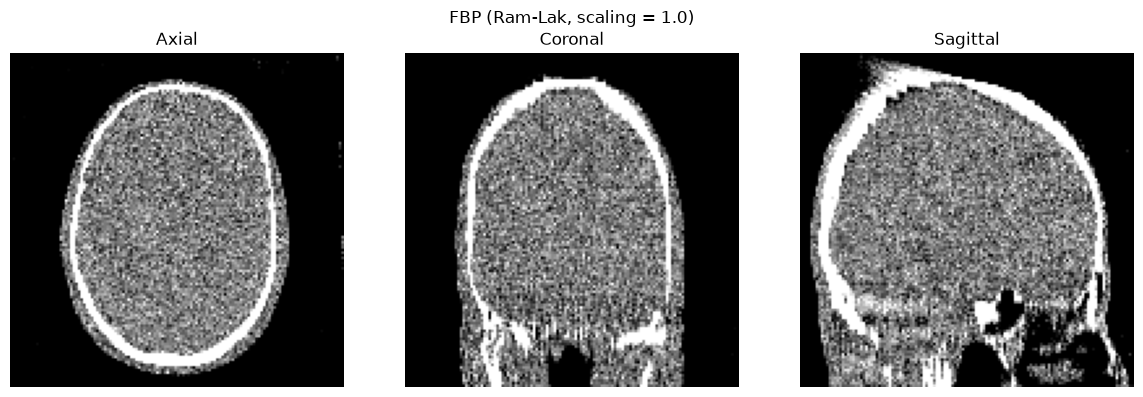

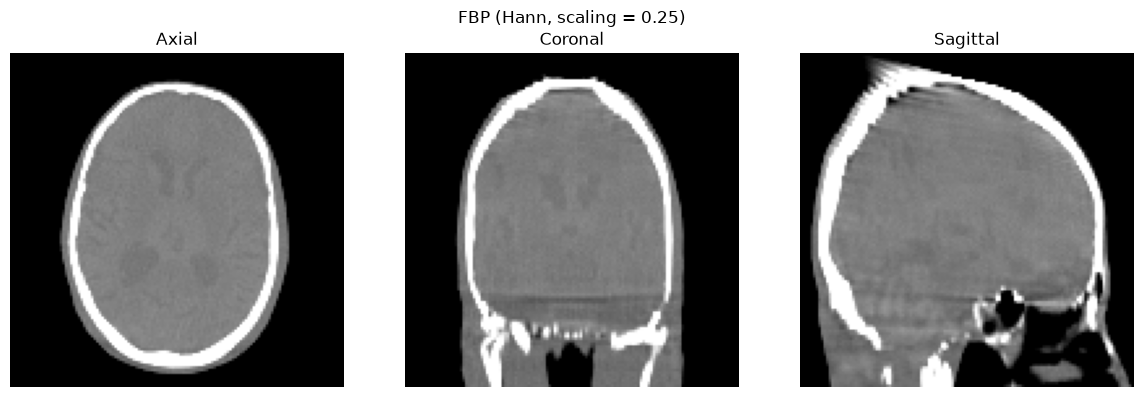

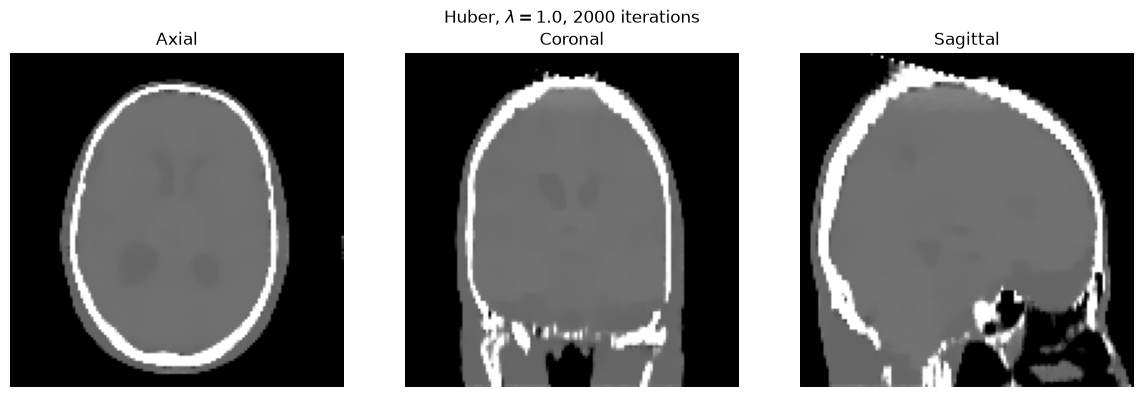

In [13]:
x_huber_3d = iterates[-1]

show_slices(x_fbp_3d, 'FBP (Ram-Lak, scaling = 1.0)', clim=clim_3d, filename='final_fbp_ramlak')
show_slices(x_hann_3d, 'FBP (Hann, scaling = 0.25)', clim=clim_3d, filename='final_fbp_hann')
show_slices(x_huber_3d, rf'Huber, $\lambda = {lam_morozov_3d}$, {checkpoints[-1]} iterations', clim=clim_3d,
            filename='final_huber')